# Specimen 03 — CIFAR-10 Image Classifier

Goal: real (small) color images. Harder than MNIST — more visual complexity, and the first specimen where overfitting becomes genuinely visible.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', device)


Using device: mps


## 1. Load & inspect

10 classes, 32×32 RGB. Plot a grid of sample images per class.

100%|██████████| 170M/170M [22:00<00:00, 129kB/s]   


50000 10000
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
[5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


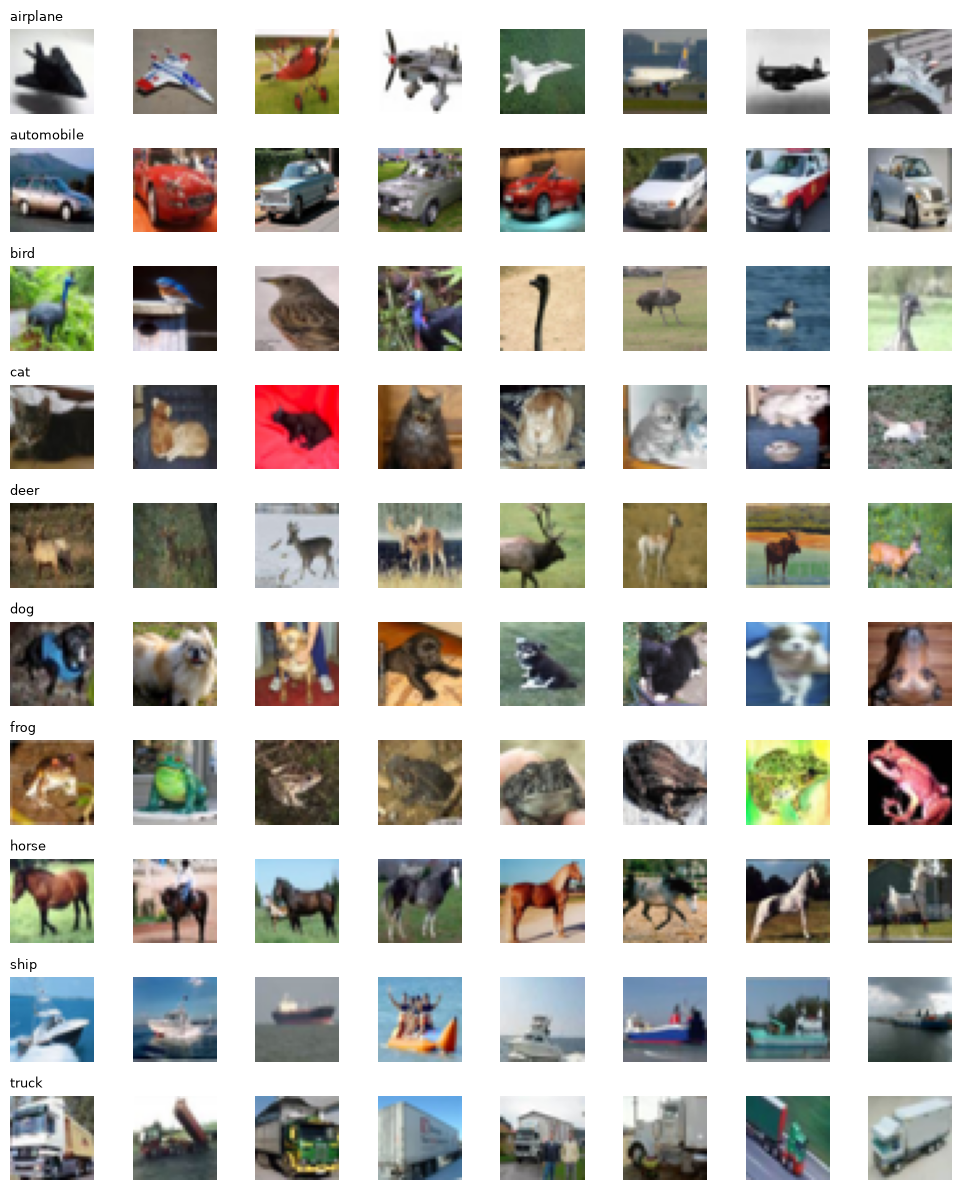

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
import numpy as np

train_raw = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
test_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=True)

classes = train_raw.classes
print(len(train_raw), len(test_raw))
print(classes)

targets = np.array(train_raw.targets)
print(np.bincount(targets))

fig, axes = plt.subplots(10, 8, figsize=(10, 12))
for class_idx in range(10):
    idxs = np.where(targets == class_idx)[0][:8]
    for j, idx in enumerate(idxs):
        img, _ = train_raw[idx]
        axes[class_idx, j].imshow(img)
        axes[class_idx, j].axis('off')
    axes[class_idx, 0].set_title(classes[class_idx], loc='left', fontsize=9)
plt.tight_layout()
plt.show()

## 2. Preprocess

Normalize per-channel mean/std. Carve a validation split out of train (CIFAR-10 ships with a fixed test set — don't touch it yet).

In [3]:
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

basic_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=basic_transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=basic_transform)

val_size = 5000
train_size = len(train_full) - val_size
train_subset, val_subset = torch.utils.data.random_split(
    train_full, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

print(len(train_subset), len(val_subset), len(test_dataset))

45000 5000 10000


## 3. Data augmentation

Random crop/flip on training data only — never on val/test.

In [4]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_aug_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
train_dataset = torch.utils.data.Subset(train_aug_full, train_subset.indices)
val_dataset = torch.utils.data.Subset(train_full, val_subset.indices)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(train_dataset), len(val_dataset), len(test_dataset))

45000 5000 10000


## 4. Build a CNN

A few conv+pool blocks then a dense head. Start smaller than you think you need.

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cnn = CNN().to(device)
print(cnn)

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


## 5. Train, tracking train vs. val

Plot loss/accuracy curves for both. This is where overfitting becomes real, unlike MNIST.

Epoch 1/12  train_loss=1.6036  train_acc=0.4107  val_loss=1.3029  val_acc=0.5324
Epoch 2/12  train_loss=1.2239  train_acc=0.5595  val_loss=1.0393  val_acc=0.6292
Epoch 3/12  train_loss=1.0459  train_acc=0.6300  val_loss=0.9272  val_acc=0.6640
Epoch 4/12  train_loss=0.9369  train_acc=0.6720  val_loss=0.8366  val_acc=0.7018
Epoch 5/12  train_loss=0.8565  train_acc=0.6996  val_loss=0.7804  val_acc=0.7246
Epoch 6/12  train_loss=0.8034  train_acc=0.7179  val_loss=0.7238  val_acc=0.7466
Epoch 7/12  train_loss=0.7550  train_acc=0.7351  val_loss=0.6874  val_acc=0.7570
Epoch 8/12  train_loss=0.7152  train_acc=0.7481  val_loss=0.6838  val_acc=0.7604
Epoch 9/12  train_loss=0.6805  train_acc=0.7609  val_loss=0.6383  val_acc=0.7736
Epoch 10/12  train_loss=0.6519  train_acc=0.7698  val_loss=0.6597  val_acc=0.7654
Epoch 11/12  train_loss=0.6324  train_acc=0.7804  val_loss=0.6221  val_acc=0.7780
Epoch 12/12  train_loss=0.6120  train_acc=0.7872  val_loss=0.6327  val_acc=0.7716
CNN training time: 468.1s

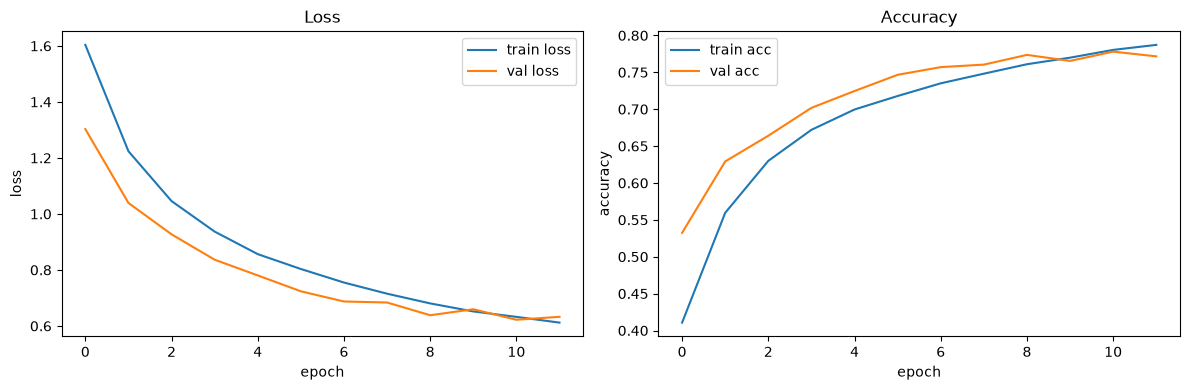

In [6]:
import time

def train_model(model, train_loader, val_loader, epochs=12, lr=1e-3, weight_decay=0.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(dim=1) == labels).sum().item()

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.4f}')

    return history

cnn_start = time.time()
cnn_history = train_model(cnn, train_loader, val_loader, epochs=12)
cnn_train_time = time.time() - cnn_start
print(f'CNN training time: {cnn_train_time:.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cnn_history['train_loss'], label='train loss')
axes[0].plot(cnn_history['val_loss'], label='val loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()
axes[0].set_title('Loss')

axes[1].plot(cnn_history['train_acc'], label='train acc')
axes[1].plot(cnn_history['val_acc'], label='val acc')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()
axes[1].set_title('Accuracy')

plt.tight_layout()
plt.show()

## 6. Tune one thing at a time

Batch norm, more conv layers, or a learning-rate schedule — change one variable, measure its actual effect on val accuracy.

In [7]:
class CNNBatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cnn_bn = CNNBatchNorm().to(device)

bn_start = time.time()
bn_history = train_model(cnn_bn, train_loader, val_loader, epochs=12)
bn_train_time = time.time() - bn_start
print(f'CNN+BatchNorm training time: {bn_train_time:.1f}s')

print(f"CNN best val acc: {max(cnn_history['val_acc']):.4f} in {cnn_train_time:.1f}s")
print(f"CNN+BatchNorm best val acc: {max(bn_history['val_acc']):.4f} in {bn_train_time:.1f}s")

Epoch 1/12  train_loss=1.4077  train_acc=0.4854  val_loss=1.0551  val_acc=0.6206
Epoch 2/12  train_loss=1.0382  train_acc=0.6270  val_loss=0.9199  val_acc=0.6680
Epoch 3/12  train_loss=0.9048  train_acc=0.6784  val_loss=0.8673  val_acc=0.6920
Epoch 4/12  train_loss=0.8206  train_acc=0.7089  val_loss=0.7752  val_acc=0.7246
Epoch 5/12  train_loss=0.7692  train_acc=0.7276  val_loss=0.7470  val_acc=0.7366
Epoch 6/12  train_loss=0.7211  train_acc=0.7440  val_loss=0.7591  val_acc=0.7314
Epoch 7/12  train_loss=0.6902  train_acc=0.7583  val_loss=0.7266  val_acc=0.7460
Epoch 8/12  train_loss=0.6615  train_acc=0.7665  val_loss=0.6732  val_acc=0.7628
Epoch 9/12  train_loss=0.6418  train_acc=0.7771  val_loss=0.6082  val_acc=0.7838
Epoch 10/12  train_loss=0.6096  train_acc=0.7856  val_loss=0.5917  val_acc=0.7894
Epoch 11/12  train_loss=0.5874  train_acc=0.7938  val_loss=0.5933  val_acc=0.7908
Epoch 12/12  train_loss=0.5734  train_acc=0.7980  val_loss=0.6224  val_acc=0.7784
CNN+BatchNorm training ti

## 7. Evaluate

Test accuracy + confusion matrix across the 10 classes. Which classes get confused (classic ones: cat/dog, automobile/truck)?

Best model: CNN+BatchNorm
CNN+BatchNorm test accuracy: 0.7894
[[894   9  37   7   8   0   3   6  27   9]
 [ 27 881   2   3   1   0   3   0  25  58]
 [ 49   1 817  34  36  15  24  14   4   6]
 [ 46   3 113 660  32  65  19  32  16  14]
 [ 25   1 119  40 753  10  20  27   4   1]
 [ 21   0  90 203  42 584   8  42   5   5]
 [ 21   4 104  84  11   6 753   7   7   3]
 [ 21   1  53  31  46  11   1 831   1   4]
 [ 70   4  17   6   2   0   0   3 882  16]
 [ 66  42  15   5   3   0   2   5  23 839]]
              precision    recall  f1-score   support

    airplane       0.72      0.89      0.80      1000
  automobile       0.93      0.88      0.91      1000
        bird       0.60      0.82      0.69      1000
         cat       0.62      0.66      0.64      1000
        deer       0.81      0.75      0.78      1000
         dog       0.85      0.58      0.69      1000
        frog       0.90      0.75      0.82      1000
       horse       0.86      0.83      0.84      1000
        ship       0

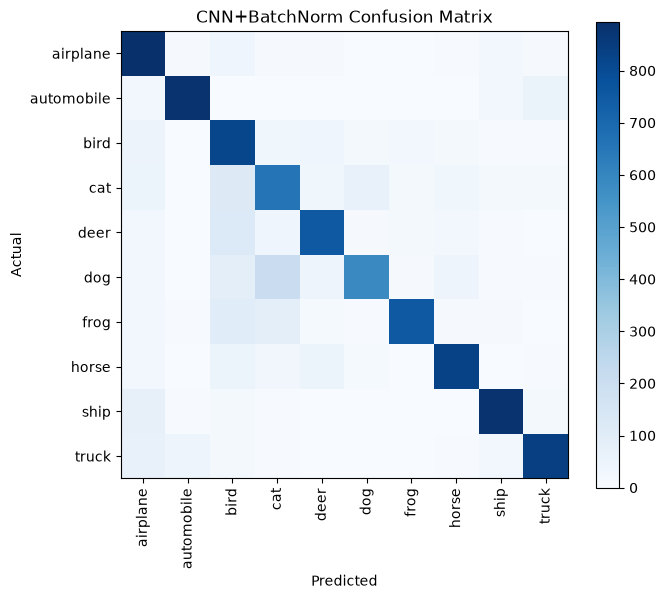

Most confused pair: true=dog predicted=cat (203 cases)


In [8]:
from sklearn.metrics import confusion_matrix, classification_report

best_model, best_name = (cnn_bn, 'CNN+BatchNorm') if max(bn_history['val_acc']) > max(cnn_history['val_acc']) else (cnn, 'CNN')
print('Best model:', best_name)

best_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        preds = outputs.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

test_acc = (all_preds == all_labels).mean()
print(f'{best_name} test accuracy: {test_acc:.4f}')

cm = confusion_matrix(all_labels, all_preds)
print(cm)
print(classification_report(all_labels, all_preds, target_names=classes))

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10), classes, rotation=90)
plt.yticks(range(10), classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'{best_name} Confusion Matrix')
plt.tight_layout()
plt.show()

off_diag = cm.copy()
np.fill_diagonal(off_diag, 0)
i, j = np.unravel_index(np.argmax(off_diag), off_diag.shape)
print(f'Most confused pair: true={classes[i]} predicted={classes[j]} ({off_diag[i, j]} cases)')

## 8. Final report

3-5 sentences: what architecture worked, what didn't, and why you think over/underfitting happened where it did.

In [9]:
gap = cnn_history['train_acc'][-1] - cnn_history['val_acc'][-1]
bn_gap = bn_history['train_acc'][-1] - bn_history['val_acc'][-1]

summary = f'''The plain CNN reached {max(cnn_history["val_acc"]) * 100:.1f}% best validation accuracy, ending with a train/val accuracy gap of {gap * 100:.1f} points.
Adding BatchNorm changed best validation accuracy to {max(bn_history["val_acc"]) * 100:.1f}%, with a final train/val gap of {bn_gap * 100:.1f} points.
{best_name} was selected for final test evaluation and scored {test_acc * 100:.1f}% test accuracy.
The most confused class pair was {classes[i]} vs {classes[j]}, matching the classic CIFAR-10 confusions this dataset is known for.
Data augmentation (random crop + flip) was applied throughout training to slow down overfitting on this harder, more visually complex dataset.'''

print(summary)

The plain CNN reached 77.8% best validation accuracy, ending with a train/val accuracy gap of 1.6 points.
Adding BatchNorm changed best validation accuracy to 79.1%, with a final train/val gap of 2.0 points.
CNN+BatchNorm was selected for final test evaluation and scored 78.9% test accuracy.
The most confused class pair was dog vs cat, matching the classic CIFAR-10 confusions this dataset is known for.
Data augmentation (random crop + flip) was applied throughout training to slow down overfitting on this harder, more visually complex dataset.
